In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/hourly-energy-consumption/DEOK_hourly.csv
/kaggle/input/hourly-energy-consumption/PJMW_hourly.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/kaggle/input/hourly-energy-consumption/AEP_hourly.csv")
df = pd.DataFrame(data)
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [6]:
df.isna().sum()

Datetime    0
AEP_MW      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Datetime"] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_values("Datetime")

In [10]:
df.index.to_series().diff().value_counts().head()

Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
0 days 00:00:00         4
Name: count, dtype: int64

In [11]:
df = df.sort_index()

In [12]:
df.index.to_series().diff().value_counts().head()

Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
0 days 00:00:00         4
Name: count, dtype: int64

In [13]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["dayofyear"] = df.index.dayofyear
df["month"] = df.index.month
df["quarter"] = df.index.quarter
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)

In [15]:
df["lag_1"] = df["AEP_MW"].shift(1)
df["lag_24"] = df["AEP_MW"].shift(24)
df["lag_168"] = df["AEP_MW"].shift(168)

In [16]:
df['rolling_mean_24'] = df['AEP_MW'].rolling(24).mean()
df['rolling_std_24'] = df['AEP_MW'].rolling(24).std()

df['rolling_mean_168'] = df['AEP_MW'].rolling(168).mean()

In [17]:
df['target'] = df['AEP_MW'].shift(-24)

In [18]:
df = df.dropna()

In [20]:
X = df.drop(columns=['AEP_MW', 'target'])
y = df['target']

In [21]:
train = df[df.index < "2016-01-01"]
test = df[df.index >= "2016-01-01"]

X_train = train.drop(columns=['AEP_MW', 'target'])
y_train = train['target']

X_test = test.drop(columns=['AEP_MW', 'target'])
y_test = test['target']

In [27]:
# XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [28]:
y_pred_xgb = xgb.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 745.4462625966908
RMSE: 984.5450318061796
R2: 0.8422127084380508


In [30]:
importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

lag_1               0.595840
lag_24              0.096789
lag_168             0.084221
dayofweek           0.077326
hour                0.044187
is_weekend          0.041105
dayofyear           0.013679
rolling_mean_168    0.010365
rolling_std_24      0.010172
rolling_mean_24     0.010148
dtype: float32

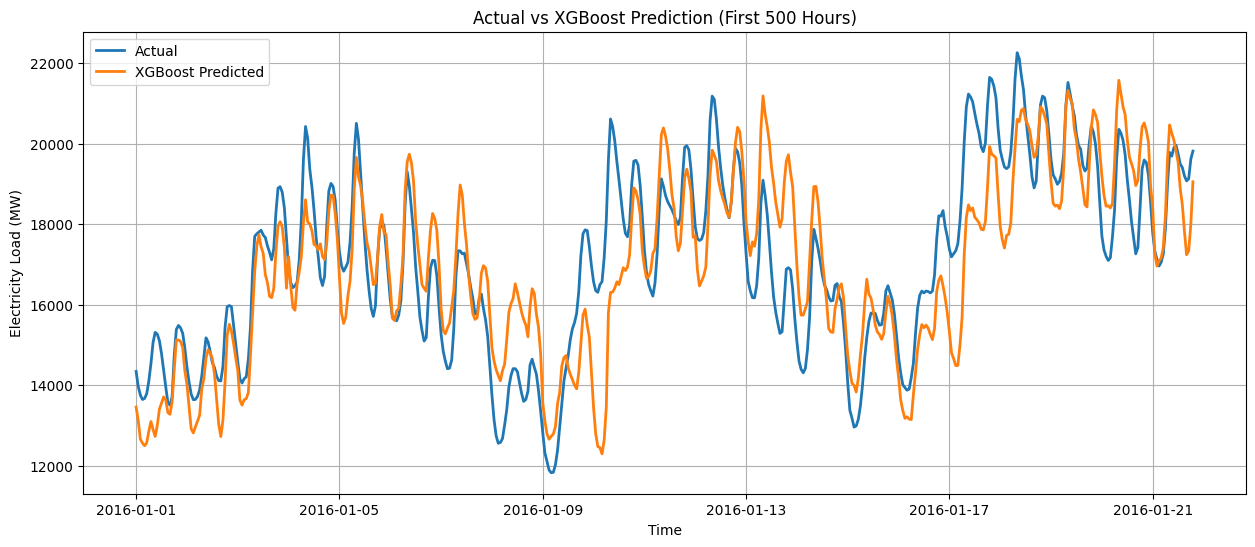

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test.index[:500], y_test.values[:500], label="Actual", linewidth=2)
plt.plot(y_test.index[:500], y_pred_xgb[:500], label="XGBoost Predicted", linewidth=2)

plt.title("Actual vs XGBoost Prediction (First 500 Hours)")
plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
import joblib

# save trained model
joblib.dump(xgb, "electricity_model.pkl")

print("Model saved successfully!")

Model saved successfully!
